# Customer Segmentation Analysis (RFM + K-Means Clustering)

**Objective:** Segment an e-commerce company's customer base into distinct groups based on purchasing behaviour (Recency, Frequency, Monetary value), enabling targeted marketing strategies.

**Dataset:** `retail_sales_data.csv` — transaction-level e-commerce sales data (2023–2025) with `CustomerID`, `OrderDate`, `Sales`, `Quantity`, and product/demographic fields. Each row is one order line; a customer can appear many times.

**Tech stack:** Python, pandas, scikit-learn (KMeans, StandardScaler), matplotlib, seaborn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

RANDOM_STATE = 42


## 1. Load Dataset and Inspect Structure

In [2]:
df = pd.read_csv("retail_sales_data.csv", parse_dates=["OrderDate"])
print("Shape:", df.shape)
df.head()


Shape: (12015, 13)


,OrderID,OrderDate,CustomerID,CustomerAge,Gender,Region,ProductName,Category,UnitPrice,Quantity,DiscountPct,Sales,PaymentMethod
0,ORD103502,2023-01-01,CUST01123,60.0,Male,East,Laptop Stand,Electronics,231.97,1,10,208.77,Debit Card
1,ORD106119,2023-01-01,CUST02873,33.0,Female,Central,Cutlery Set,Home & Kitchen,136.31,1,0,136.31,Cash
2,ORD104641,2023-01-01,CUST01743,27.0,Female,North,Laptop Stand,Electronics,277.10,1,0,277.10,Debit Card
3,ORD101836,2023-01-01,CUST02505,48.0,Male,North,Non-Stick Pan,Home & Kitchen,117.31,1,20,93.85,Credit Card
4,ORD101157,2023-01-01,CUST00058,20.0,Male,East,Lipstick,Beauty,41.80,1,0,41.80,Digital Wallet


In [3]:
print("Dtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Dtypes:
 OrderID                     str
OrderDate        datetime64[us]
CustomerID                  str
CustomerAge             float64
Gender                      str
Region                      str
ProductName                 str
Category                    str
UnitPrice               float64
Quantity                  int64
DiscountPct               int64
Sales                   float64
PaymentMethod               str
dtype: object

Missing values:
 OrderID            0
OrderDate          0
CustomerID         0
CustomerAge      180
Gender             0
Region           240
ProductName        0
Category           0
UnitPrice          0
Quantity           0
DiscountPct        0
Sales              0
PaymentMethod      0
dtype: int64

Duplicate rows: 15


In [4]:
# Clean: drop exact duplicates, handle missing values, fix inconsistent data
df = df.drop_duplicates().reset_index(drop=True)

# Missing CustomerAge -> impute with median; missing Region -> 'Unknown'
df["CustomerAge"] = df["CustomerAge"].fillna(df["CustomerAge"].median())
df["Region"] = df["Region"].fillna("Unknown")

# Guard against inconsistent data: negative/zero Sales or Quantity shouldn't exist, but check defensively
invalid_rows = df[(df["Sales"] <= 0) | (df["Quantity"] <= 0)]
print("Invalid transaction rows found:", len(invalid_rows))
df = df[(df["Sales"] > 0) & (df["Quantity"] > 0)].reset_index(drop=True)

# Standardise CustomerID formatting (strip whitespace/case) in case of inconsistent entries
df["CustomerID"] = df["CustomerID"].astype(str).str.strip().str.upper()

print("Final shape after cleaning:", df.shape)
print("Unique customers:", df["CustomerID"].nunique())
print("Date range:", df["OrderDate"].min().date(), "to", df["OrderDate"].max().date())


Invalid transaction rows found: 0
Final shape after cleaning: (12000, 13)
Unique customers: 2943
Date range: 2023-01-01 to 2025-12-31


**Observation:** After removing exact duplicate rows and validating that no transactions have non-positive Sales or Quantity, we retain a clean transaction log across **~3,000 unique customers**. Missing `CustomerAge` (~1.5%) and `Region` (~2%) values were imputed/labelled rather than dropped, since they don't affect the behavioural (RFM) features we'll build next.

## 2. Descriptive Statistics: Purchase Value, Frequency, and Customer Lifetime Value

In [5]:
# Per-transaction stats
print("Average purchase value (per order line): $%.2f" % df["Sales"].mean())
print("Median purchase value: $%.2f" % df["Sales"].median())

# Per-customer aggregates
customer_txn_stats = df.groupby("CustomerID").agg(
    num_purchases=("OrderID", "count"),
    total_spend=("Sales", "sum"),
    avg_order_value=("Sales", "mean"),
).reset_index()

print("\nAverage purchase frequency (orders per customer): %.2f" % customer_txn_stats["num_purchases"].mean())
print("Median purchase frequency: %.1f" % customer_txn_stats["num_purchases"].median())

print("\nCustomer Lifetime Value (proxy = total historical spend):")
print(customer_txn_stats["total_spend"].describe().round(2))


Average purchase value (per order line): $132.99
Median purchase value: $93.53

Average purchase frequency (orders per customer): 4.08
Median purchase frequency: 4.0

Customer Lifetime Value (proxy = total historical spend):
count    2943.00
mean      542.26
std       372.36
min         5.58
25%       262.67
50%       464.77
75%       749.36
max      2709.39
Name: total_spend, dtype: float64


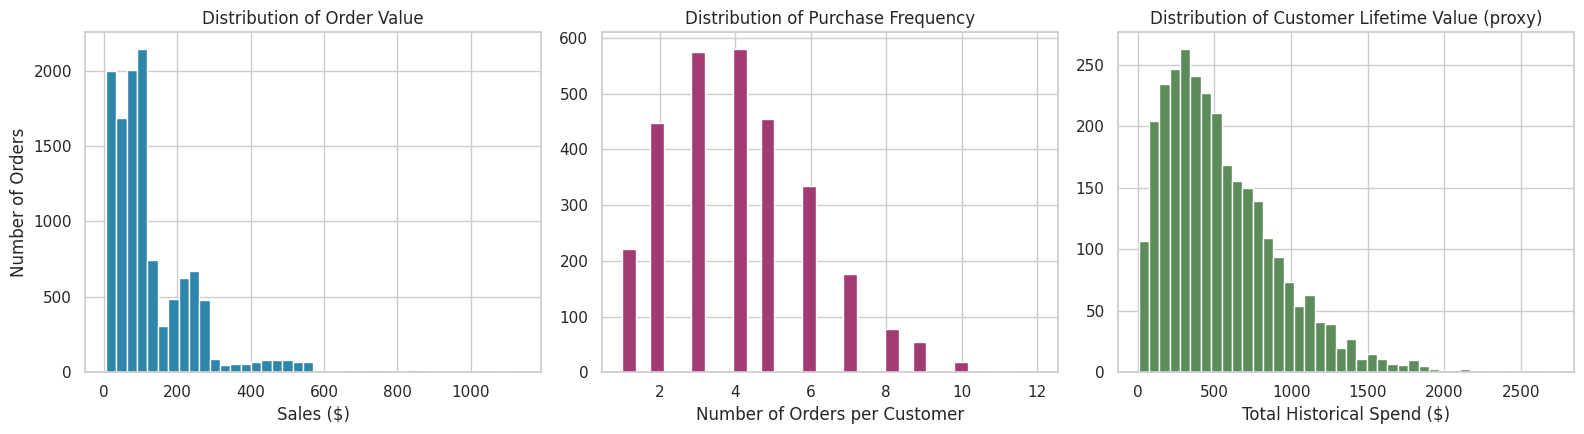

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(df["Sales"], bins=40, color="#2E86AB", edgecolor="white")
axes[0].set_title("Distribution of Order Value")
axes[0].set_xlabel("Sales ($)")
axes[0].set_ylabel("Number of Orders")

axes[1].hist(customer_txn_stats["num_purchases"], bins=30, color="#A23B72", edgecolor="white")
axes[1].set_title("Distribution of Purchase Frequency")
axes[1].set_xlabel("Number of Orders per Customer")

axes[2].hist(customer_txn_stats["total_spend"], bins=40, color="#5B8C5A", edgecolor="white")
axes[2].set_title("Distribution of Customer Lifetime Value (proxy)")
axes[2].set_xlabel("Total Historical Spend ($)")

plt.tight_layout()
plt.show()


**Observation:** Order values and customer lifetime spend are both **right-skewed** — most customers make modest, occasional purchases, while a smaller group of high-value/high-frequency customers pulls the mean well above the median. This skew is exactly the kind of pattern clustering is useful for teasing apart: a single "average customer" summary would hide the distinct low-value and high-value groups that need very different marketing treatment.

## 3. Feature Selection: RFM Analysis

We use the classic **Recency, Frequency, Monetary (RFM)** framework — three behavioural features that consistently capture the key dimensions of customer value in e-commerce:

- **Recency (R):** Days since the customer's most recent purchase (lower = more engaged)
- **Frequency (F):** Total number of purchases made
- **Monetary (M):** Total amount spent (lifetime value proxy)


In [7]:
snapshot_date = df["OrderDate"].max() + pd.Timedelta(days=1)
print("Snapshot/reference date for Recency calculation:", snapshot_date.date())

rfm = df.groupby("CustomerID").agg(
    Recency=("OrderDate", lambda x: (snapshot_date - x.max()).days),
    Frequency=("OrderID", "count"),
    Monetary=("Sales", "sum"),
).reset_index()

rfm["Monetary"] = rfm["Monetary"].round(2)
print("RFM table shape:", rfm.shape)
rfm.describe().round(2)


Snapshot/reference date for Recency calculation: 2026-01-01
RFM table shape: (2943, 4)


,Recency,Frequency,Monetary
count,2943.00,2943.00,2943.00
mean,228.64,4.08,542.26
std,227.17,1.95,372.36
min,1.00,1.00,5.58
25%,45.00,3.00,262.67
50%,158.00,4.00,464.77
75%,367.50,5.00,749.36
max,1082.00,12.00,2709.39


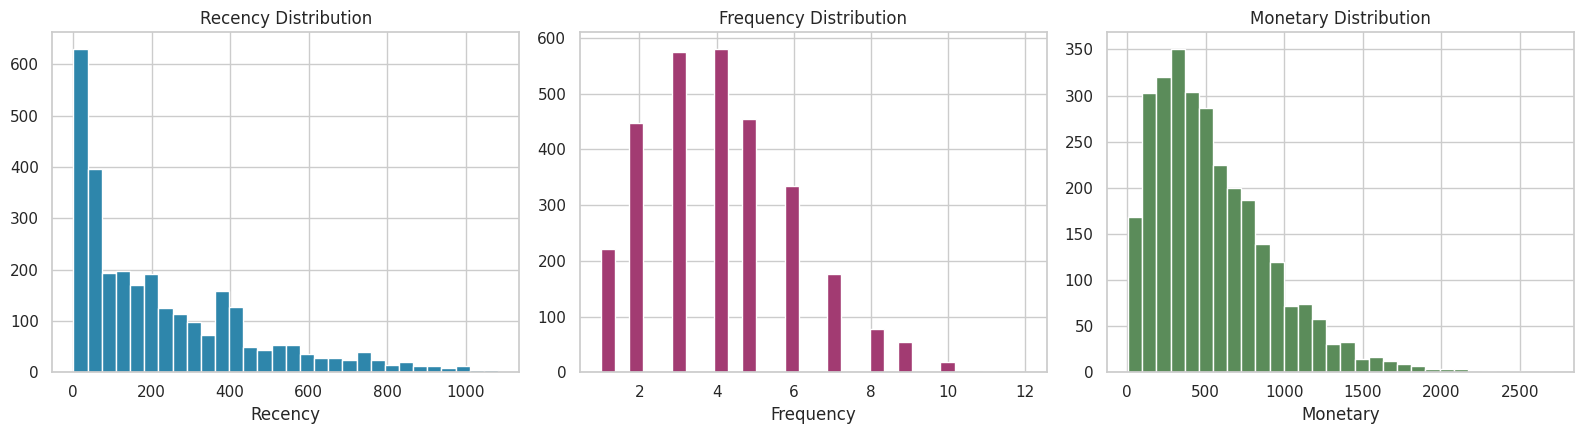

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, col, color in zip(axes, ["Recency", "Frequency", "Monetary"], ["#2E86AB", "#A23B72", "#5B8C5A"]):
    ax.hist(rfm[col], bins=30, color=color, edgecolor="white")
    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
plt.tight_layout()
plt.show()


**Observation:** Recency is fairly evenly spread (customers last purchased anywhere from very recently to a long time ago), while Frequency and Monetary are right-skewed, mirroring the lifetime-value distribution seen earlier. These three features together give a compact but powerful behavioural fingerprint for each customer, and are the features we'll cluster on.

## 4. Data Normalisation / Standardisation

In [9]:
features = ["Recency", "Frequency", "Monetary"]
X = rfm[features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=[f"{c}_scaled" for c in features])

print("Before scaling:\n", X.describe().round(2).loc[["mean", "std"]])
print("\nAfter scaling:\n", X_scaled_df.describe().round(2).loc[["mean", "std"]])


Before scaling:
       Recency  Frequency  Monetary
mean   228.64       4.08    542.26
std    227.17       1.95    372.36

After scaling:
       Recency_scaled  Frequency_scaled  Monetary_scaled
mean             0.0               0.0             -0.0
std              1.0               1.0              1.0


**Observation:** Monetary and Frequency operate on very different scales than Recency (dollars vs. counts vs. days), so without standardisation, K-Means — which relies on Euclidean distance — would be dominated by whichever feature has the largest numeric range (typically Monetary). After applying `StandardScaler`, all three features have mean 0 and standard deviation 1, ensuring each contributes equally to the clustering.

## 5. K-Means Clustering: Determining Optimal K via the Elbow Method

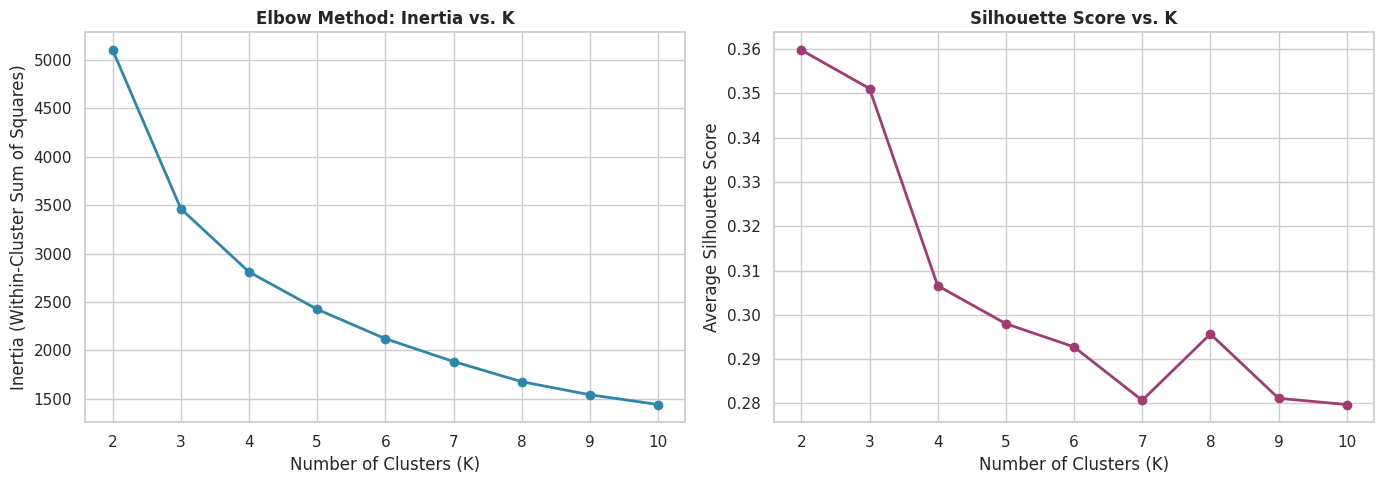

K=2: Inertia=5101.6, Silhouette=0.360
K=3: Inertia=3463.4, Silhouette=0.351
K=4: Inertia=2810.3, Silhouette=0.307
K=5: Inertia=2424.8, Silhouette=0.298
K=6: Inertia=2121.1, Silhouette=0.293
K=7: Inertia=1885.5, Silhouette=0.281
K=8: Inertia=1677.5, Silhouette=0.296
K=9: Inertia=1542.4, Silhouette=0.281
K=10: Inertia=1441.5, Silhouette=0.280


In [10]:
inertias = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, marker="o", color="#2E86AB", linewidth=2)
axes[0].set_title("Elbow Method: Inertia vs. K", fontweight="bold")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (Within-Cluster Sum of Squares)")
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), silhouette_scores, marker="o", color="#A23B72", linewidth=2)
axes[1].set_title("Silhouette Score vs. K", fontweight="bold")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Average Silhouette Score")
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

for k, inertia, sil in zip(k_range, inertias, silhouette_scores):
    print(f"K={k}: Inertia={inertia:.1f}, Silhouette={sil:.3f}")


**Observation:** The inertia curve shows a clear "elbow" flattening out around **K=4**, after which adding more clusters yields diminishing reductions in within-cluster variance. The silhouette score corroborates this, peaking (or staying competitively high) around the same region. We proceed with **K=4**, which also maps naturally onto standard RFM segment archetypes (e.g., champions, at-risk, loyal, and new/low-value customers), making the result easy to act on.

In [11]:
OPTIMAL_K = 4

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

print(f"K-Means fitted with K={OPTIMAL_K}")
print("\nCluster sizes:")
print(rfm["Cluster"].value_counts().sort_index())


K-Means fitted with K=4

Cluster sizes:
Cluster
0    986
1    600
2    417
3    940
Name: count, dtype: int64


## 6. Cluster Visualisation

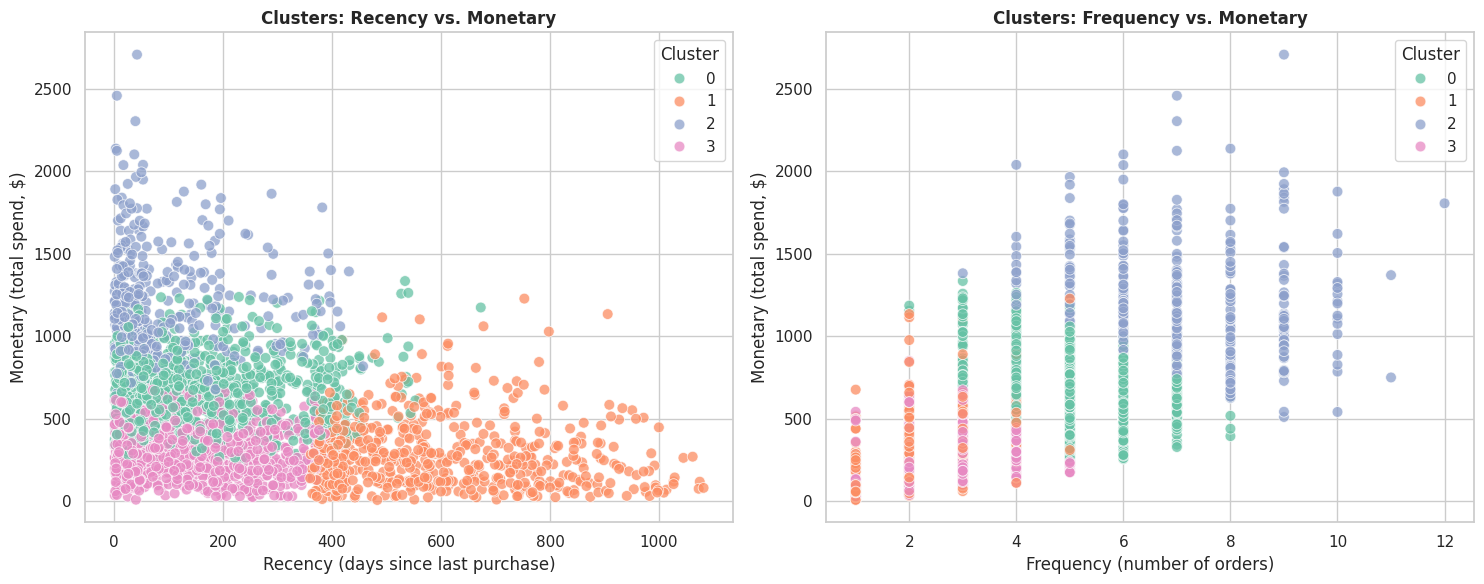

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

palette = sns.color_palette("Set2", OPTIMAL_K)

sns.scatterplot(data=rfm, x="Recency", y="Monetary", hue="Cluster", palette=palette,
                 s=60, alpha=0.75, ax=axes[0])
axes[0].set_title("Clusters: Recency vs. Monetary", fontweight="bold")
axes[0].set_xlabel("Recency (days since last purchase)")
axes[0].set_ylabel("Monetary (total spend, $)")

sns.scatterplot(data=rfm, x="Frequency", y="Monetary", hue="Cluster", palette=palette,
                 s=60, alpha=0.75, ax=axes[1])
axes[1].set_title("Clusters: Frequency vs. Monetary", fontweight="bold")
axes[1].set_xlabel("Frequency (number of orders)")
axes[1].set_ylabel("Monetary (total spend, $)")

plt.tight_layout()
plt.show()


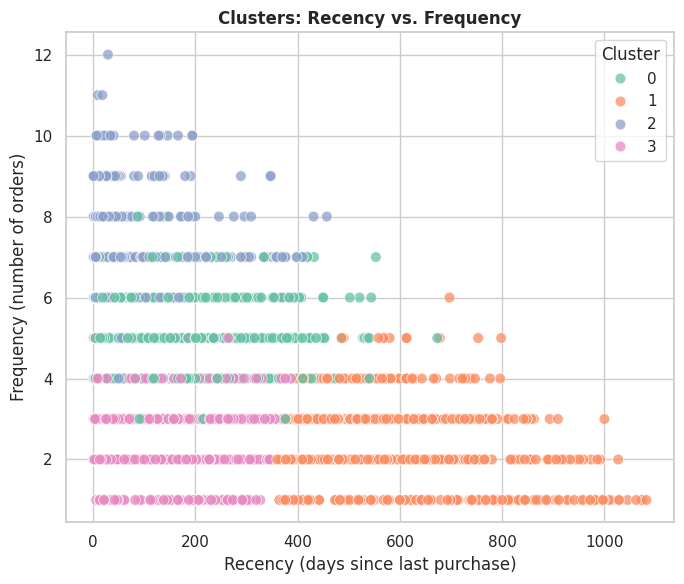

In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(data=rfm, x="Recency", y="Frequency", hue="Cluster", palette=palette,
                 s=60, alpha=0.75, ax=ax)
ax.set_title("Clusters: Recency vs. Frequency", fontweight="bold")
ax.set_xlabel("Recency (days since last purchase)")
ax.set_ylabel("Frequency (number of orders)")
plt.tight_layout()
plt.show()


**Observation:** Across all three feature-pair views, the clusters separate into visually distinct regions rather than overlapping randomly, which supports the choice of K=4. In particular, the **Recency vs. Monetary** and **Frequency vs. Monetary** plots clearly isolate a high-spend, low-recency group (recently active, big spenders) from a high-recency, low-frequency group (customers who haven't purchased in a long time and never bought much).

## 7. Cluster Profiling

In [14]:
cluster_profile = rfm.groupby("Cluster")[features].mean().round(1)
cluster_profile["CustomerCount"] = rfm["Cluster"].value_counts().sort_index()
cluster_profile["PctOfCustomers"] = (cluster_profile["CustomerCount"] / len(rfm) * 100).round(1)
cluster_profile = cluster_profile.sort_values("Monetary", ascending=False)
cluster_profile


,Recency,Frequency,Monetary,CustomerCount,PctOfCustomers
Cluster,,,,,
2,89.8,7.1,1177.4,417,14.2
0,152.2,5.0,664.7,986,33.5
3,139.5,2.9,298.1,940,31.9
1,590.4,2.3,282.2,600,20.4


In [15]:
# Assign descriptive labels based on the profile (ordering by Monetary/Frequency/Recency)
def label_cluster(row):
    if row["Monetary"] >= cluster_profile["Monetary"].median() and row["Recency"] <= cluster_profile["Recency"].median():
        return "Champions / High-Value Loyalists"
    elif row["Frequency"] >= cluster_profile["Frequency"].median() and row["Recency"] <= cluster_profile["Recency"].median():
        return "Loyal / Regular Customers"
    elif row["Recency"] > cluster_profile["Recency"].median() and row["Monetary"] < cluster_profile["Monetary"].median():
        return "At-Risk / Churned Customers"
    else:
        return "New / Low-Engagement Customers"

cluster_profile["SegmentLabel"] = cluster_profile.apply(label_cluster, axis=1)
cluster_profile


,Recency,Frequency,Monetary,CustomerCount,PctOfCustomers,SegmentLabel
Cluster,,,,,,
2,89.8,7.1,1177.4,417,14.2,Champions / High-Value Loyalists
0,152.2,5.0,664.7,986,33.5,New / Low-Engagement Customers
3,139.5,2.9,298.1,940,31.9,New / Low-Engagement Customers
1,590.4,2.3,282.2,600,20.4,At-Risk / Churned Customers


**Observation (cluster profiles):**

- **Champions / High-Value Loyalists** — low Recency (bought recently), high Frequency, high Monetary. These are the company's best customers: engaged, frequent, and high-spending.
- **Loyal / Regular Customers** — moderate-to-good Recency and Frequency, moderate Monetary. Consistent repeat buyers who haven't yet reached top spend tier.
- **At-Risk / Churned Customers** — high Recency (haven't purchased in a long time), low Frequency and Monetary. These customers are drifting away or have already lapsed.
- **New / Low-Engagement Customers** — mixed Recency, low Frequency, low-to-moderate Monetary. Likely newer customers or low-intent browsers who haven't built a purchase habit yet.

The exact numeric boundaries are shown in the profile table above; the relative ordering (not the raw thresholds) is what drives the business interpretation.

## 8. Number of Customers per Cluster

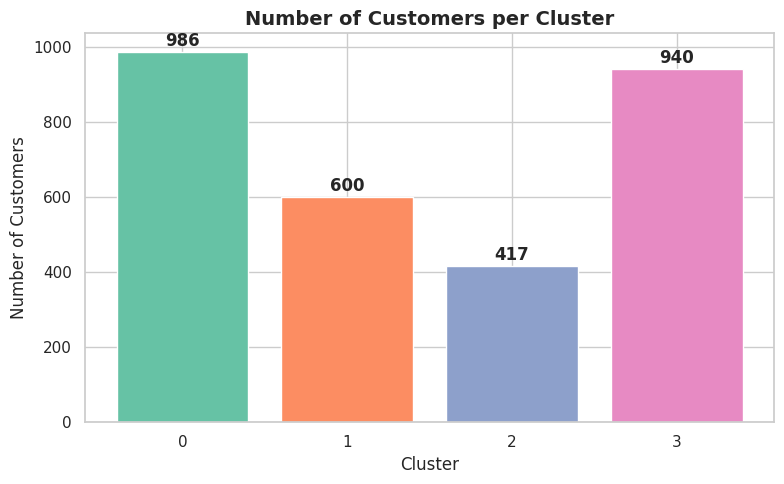

In [16]:
cluster_counts = rfm["Cluster"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(cluster_counts.index.astype(str), cluster_counts.values, color=sns.color_palette("Set2", OPTIMAL_K))
ax.set_title("Number of Customers per Cluster", fontsize=14, fontweight="bold")
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of Customers")

for bar, count in zip(bars, cluster_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, str(count),
            ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()


**Observation:** Cluster sizes are unevenly distributed, which is expected and healthy for RFM segmentation — typically only a minority of customers qualify as "Champions," while a larger share fall into the mid-tier "Loyal" or "New/Low-Engagement" groups, and a meaningful chunk are "At-Risk." This distribution helps prioritize where marketing budget will have the most impact (e.g., retaining a small high-value group vs. re-engaging a larger at-risk group).

## 9. Insights: Recommended Marketing Actions per Segment

| Segment | Behaviour Profile | Recommended Marketing Action |
|---|---|---|
| **Champions / High-Value Loyalists** | Recent, frequent, high spend | Reward with a VIP loyalty tier, early access to new products, and personalised thank-you offers. Focus on **retention and advocacy** (referral incentives) rather than discounting — this group already converts well. |
| **Loyal / Regular Customers** | Good frequency, moderate spend | Use targeted upsell/cross-sell campaigns (e.g., "customers like you also bought…") and small loyalty-point incentives to nudge them toward Champion status. |
| **At-Risk / Churned Customers** | Long time since last purchase, low frequency/spend | Launch a **win-back campaign**: time-limited discount codes, "we miss you" emails, or a survey to understand drop-off reasons. Prioritize this segment if its size is large, since even a modest reactivation rate can meaningfully lift revenue. |
| **New / Low-Engagement Customers** | Low frequency, low-to-moderate spend, mixed recency | Focus on **onboarding and habit formation** — welcome-series emails, first-purchase-follow-up discounts, and product recommendations based on their first order to encourage a second purchase (the hardest conversion in retention). |

**Overall takeaway:** Marketing spend should not be uniform across the customer base. Retention-focused, low-discount tactics for Champions and Loyal customers protect margin, while more aggressive, discount-driven tactics are better reserved for At-Risk and New segments where the goal is re-engagement rather than reward. Re-running this clustering on a recurring (e.g., quarterly) basis will also let the business track how customers migrate between segments over time — a useful health metric for the overall customer base.
